In [ ]:
# @title Simulasi SFD: Proyeksi Subsistem Kebersihan Lingkungan (Fully Synchronized)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [ ]:
# ==========================================
# 1. KONFIGURASI PARAMETER (SINKRON 100% DENGAN POPULASI BAU)
# ==========================================
start_date = date(2023, 1, 1)
end_date = date(2045, 12, 31)
days = (end_date - start_date).days + 1

# --- A. Parameter Populasi & Dinamika Sistem ---
batas_overtourism = 2752         # Kapasitas fisik (jiwa/hari)
lama_tinggal_normal = 3          # Baseline lama tinggal (hari)

rate_23_24 = 0.3179  # Lonjakan 2023 ke 2024
rate_24_25 = 0.1085  # Lonjakan 2024 ke 2025
rate_bau   = 0.0468  # Pertumbuhan normal BAU mulai 2026

# --- B. Parameter Timbulan Residu ---
timbulan_sampah_per_wisatawan = 0.5 # kg/orang/hari

# --- C. Parameter Kapasitas Pengelolaan (Skenario Stagnan) ---
kapasitas_pembersihan_real = 1000 # kg/hari
stock_sampah = 500                # kg awal

In [ ]:
# ==========================================
# 2. MESIN SIMULASI SYSTEM DYNAMICS (INTEGRATED)
# ==========================================
dates = []
data_timbulan = []
data_pembersihan = []
data_stock = []

# Inisialisasi awal populasi dan reputasi (Sama persis dengan Kodingan Populasi)
stock_populasi = 1009.6
reputasi_destinasi = 1.0

curr_date = start_date

for _ in range(days):
    dates.append(curr_date)
    year = curr_date.year

    # --- FASE 1: UPDATE DINAMIKA POPULASI (MENGGUNAKAN SMOOTH DECLINE) ---
    if year == 2023:
        laju_pertumbuhan_hr = (1 + rate_23_24) ** (1/365) - 1
    elif year == 2024:
        laju_pertumbuhan_hr = (1 + rate_24_25) ** (1/365) - 1
    else:
        laju_pertumbuhan_hr = (1 + rate_bau) ** (1/365) - 1

    # Mekanisme Degradasi Reputasi (Feedback Loop)
    rasio_kepadatan = stock_populasi / batas_overtourism
    if rasio_kepadatan > 1.0:
        penalti_dinamis = (rasio_kepadatan - 1.0) * 0.0004
        reputasi_destinasi -= penalti_dinamis
    reputasi_destinasi = max(0.80, reputasi_destinasi)

    # Update Stock Populasi
    laju_kepergian = stock_populasi / lama_tinggal_normal
    kedatangan_normal = (stock_populasi / lama_tinggal_normal) + (stock_populasi * laju_pertumbuhan_hr)
    laju_kedatangan = kedatangan_normal * reputasi_destinasi

    stock_populasi += (laju_kedatangan - laju_kepergian)
    stock_populasi = max(0, stock_populasi)


    # --- FASE 2: UPDATE SUBSISTEM KEBERSIHAN LINGKUNGAN ---
    # Timbulan sampah kini dihitung dari populasi riil yang sudah kena efek reputasi
    laju_timbulan = stock_populasi * timbulan_sampah_per_wisatawan

    sampah_tersedia = stock_sampah + laju_timbulan
    laju_pembersihan = min(kapasitas_pembersihan_real, sampah_tersedia)

    stock_sampah = stock_sampah + laju_timbulan - laju_pembersihan
    stock_sampah = max(0, stock_sampah)

    # Simpan Data
    data_timbulan.append(laju_timbulan)
    data_pembersihan.append(laju_pembersihan)
    data_stock.append(stock_sampah)

    curr_date += timedelta(days=1)

In [ ]:
# ==========================================
# 3. BENTUK DATAFRAME
# ==========================================
df = pd.DataFrame({
    "Date": pd.to_datetime(dates),
    "Timbulan": data_timbulan,
    "Pembersihan": data_pembersihan,
    "Stock_Akumulasi_Sampah": data_stock
})

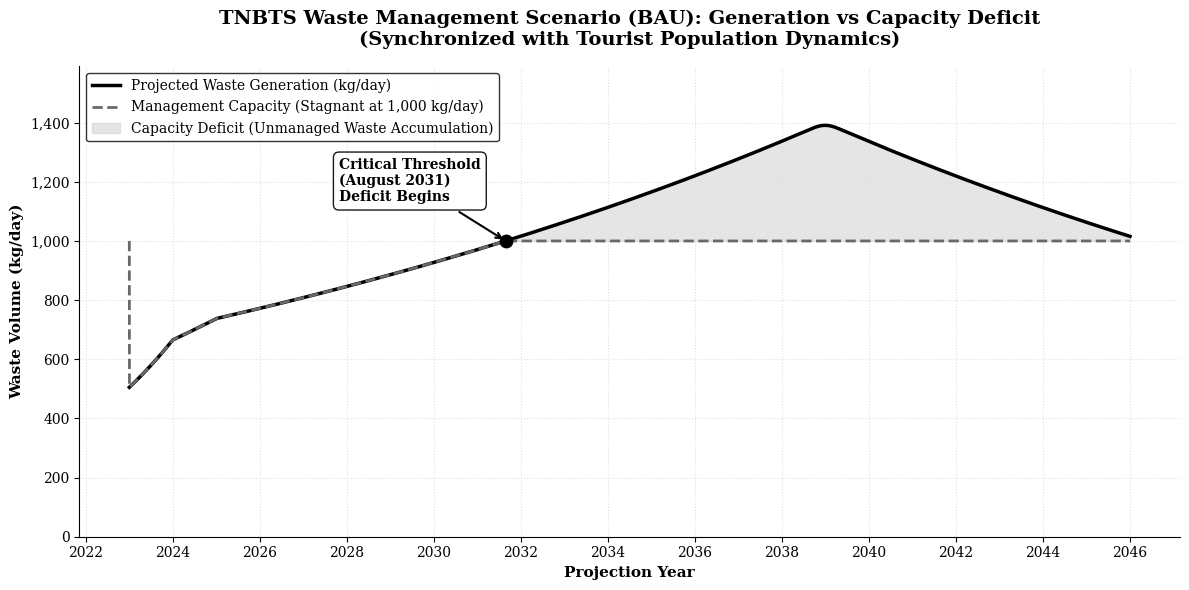

In [ ]:
# ==========================================
# 4. VISUALISASI MONOKROM AKADEMIS (ENGLISH COPY)
# ==========================================
plt.rcParams.update({
    'font.family': 'serif', 'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black',
    'ytick.color': 'black', 'axes.grid': True, 'grid.color': '#e0e0e0',
    'grid.linestyle': ':', 'legend.frameon': True, 'legend.edgecolor': 'black'
})

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Generation vs Capacity
ax1.plot(df["Date"], df["Timbulan"], color="black", linestyle="-", linewidth=2.5,
         label="Projected Waste Generation (kg/day)")
ax1.plot(df["Date"], df["Pembersihan"], color="dimgray", linestyle="--", linewidth=2,
         label="Management Capacity (Stagnant at 1,000 kg/day)")

# Highlight capacity deficit (Arsiran Defisit)
ax1.fill_between(df["Date"], df["Pembersihan"], df["Timbulan"],
                 where=(df["Timbulan"] > df["Pembersihan"]),
                 color="#C0C0C0", alpha=0.4,
                 label="Capacity Deficit (Unmanaged Waste Accumulation)")

# Anotasi Titik Kritis (Kapan sampah mulai tak tertangani)
df_cross = df[df["Timbulan"] > df["Pembersihan"]].head(1)
if not df_cross.empty:
    cross_date = df_cross["Date"].iloc[0]
    cross_val = df_cross["Timbulan"].iloc[0]
    ax1.scatter(cross_date, cross_val, color="black", s=80, zorder=5)
    ax1.annotate(
        f"Critical Threshold\n({cross_date.strftime('%B %Y')})\nDeficit Begins",
        xy=(cross_date, cross_val),
        xytext=(-120, 60), textcoords="offset points",
        fontsize=10, weight='bold', ha="left", va="top",
        arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.9)
    )

# Formatting Sumbu & Judul
ax1.set_xlabel('Projection Year', fontsize=11, weight='bold')
ax1.set_ylabel('Waste Volume (kg/day)', fontsize=11, weight='bold')
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ",")))
ax1.set_ylim(bottom=0, top=max(df["Timbulan"]) + 200)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(loc="upper left", fontsize=10)

plt.title("TNBTS Waste Management Scenario (BAU): Generation vs Capacity Deficit\n(Synchronized with Tourist Population Dynamics)",
          fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 5. EVALUASI MODEL SUBSISTEM LINGKUNGAN (MAPE)
# ==========================================

# 1. Agregasi data harian simulasi menjadi rata-rata tahunan
df['Tahun'] = df['Date'].dt.year
df_tahunan_lingkungan = df.groupby('Tahun').agg(
    Rerata_Timbulan_Harian=('Timbulan', 'mean')
).reset_index()

# 2. Masukkan Data Aktual (Riil) Timbulan Sampah
# CATATAN: Ganti angka di bawah ini dengan data riil rata-rata sampah harian (kg/hari)
# yang Anda dapatkan dari studi literatur atau instansi terkait untuk tahun 2023 & 2024.
data_aktual_sampah = {
    2023: 504.8,  # Contoh: Rata-rata 504.8 kg sampah/hari di tahun 2023
    2024: 663.5   # Contoh: Rata-rata 663.5 kg sampah/hari di tahun 2024
}

# Buat DataFrame untuk data aktual
df_aktual_lingkungan = pd.DataFrame(list(data_aktual_sampah.items()), columns=['Tahun', 'Aktual_Timbulan'])

# 3. Gabungkan Data Aktual dengan Data Hasil Simulasi
df_eval_lingkungan = pd.merge(df_aktual_lingkungan, df_tahunan_lingkungan, on='Tahun', how='inner')

# 4. Hitung APE (Absolute Percentage Error) dan MAPE
df_eval_lingkungan['APE'] = np.abs((df_eval_lingkungan['Aktual_Timbulan'] - df_eval_lingkungan['Rerata_Timbulan_Harian']) / df_eval_lingkungan['Aktual_Timbulan']) * 100
mape_lingkungan = df_eval_lingkungan['APE'].mean()

# 5. Tampilkan Hasil Evaluasi
print("\n" + "="*70)
print("   EVALUASI MAPE: SUBSISTEM KEBERSIHAN LINGKUNGAN (TIMBULAN SAMPAH)")
print("="*70)
print(df_eval_lingkungan[['Tahun', 'Aktual_Timbulan', 'Rerata_Timbulan_Harian', 'APE']].rename(
    columns={'Aktual_Timbulan': 'Aktual (kg/hari)', 'Rerata_Timbulan_Harian': 'Simulasi (kg/hari)', 'APE': 'Error (%)'}
).round(2).to_string(index=False))
print("-" * 70)
print(f"NILAI MAPE SUBSISTEM LINGKUNGAN : {mape_lingkungan:.2f}%")

# Kategorisasi standar akurasi
if mape_lingkungan < 10:
    kategori_ling = "Sangat Akurat (Highly Accurate)"
elif mape_lingkungan < 20:
    kategori_ling = "Baik (Good)"
elif mape_lingkungan < 50:
    kategori_ling = "Cukup (Reasonable)"
else:
    kategori_ling = "Kurang Akurat (Inaccurate)"

print(f"KATEGORI AKURASI                : {kategori_ling}")
print("=" * 70)


   EVALUASI MAPE: SUBSISTEM KEBERSIHAN LINGKUNGAN (TIMBULAN SAMPAH)
 Tahun  Aktual (kg/hari)  Simulasi (kg/hari)  Error (%)
  2023             504.8              581.57      15.21
  2024             663.5              700.95       5.64
----------------------------------------------------------------------
NILAI MAPE SUBSISTEM LINGKUNGAN : 10.43%
KATEGORI AKURASI                : Baik (Good)


In [ ]:
# @title Simulasi SFD: Subsistem Kebersihan Lingkungan (Intervention - Synchronized)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [ ]:
# ==========================================
# 1. KONFIGURASI PARAMETER (SINKRON & TERKALIBRASI)
# ==========================================
start_date = date(2023, 1, 1)
end_date = date(2045, 12, 31)
days = (end_date - start_date).days + 1

# --- A. Parameter Dasar (Sama dengan BAU) ---
batas_overtourism = 2752
lama_tinggal_normal = 3
r_dom_23_24 = 0.3179; r_man_23_24 = 0.508  # Estimasi historis
r_dom_24_25 = 0.1085; r_man_24_25 = -0.11

# --- B. Parameter Intervensi ---
elastisitas_harga = -0.504
tarif_dom_lama = ((5 * 54000) + (2 * 79000)) / 7
tarif_dom_baru = ((5 * 58320) + (2 * 90850)) / 7
shock_dom = ((tarif_dom_baru - tarif_dom_lama) / tarif_dom_lama) * elastisitas_harga
shock_man = ((318750 - 255000) / 255000) * elastisitas_harga

daily_growth_int = (1 + 0.035) ** (1 / 365) - 1 # Pertumbuhan pasca-intervensi melandai

# --- C. Parameter Kapasitas & Lingkungan ---
timbulan_sampah_per_wisatawan = 0.5
kapasitas_int = 1000  # kg/hari awal
daily_budget_growth = (1 + 0.05) ** (1 / 365) - 1 # Anggaran naik 5% per tahun mulai 2026

In [ ]:
# ==========================================
# 2. MESIN SIMULASI (STOCK & FLOW IDENTIK DENGAN BAU)
# ==========================================
dates = []
data_timbulan_int = []
data_kapasitas_int = []

# Stock awal dipisah agar shock harga bisa diaplikasikan spesifik
stock_dom = 355297 / 365
stock_man = 13210 / 365
reputasi_destinasi = 1.0

curr_date = start_date

for _ in range(days):
    dates.append(curr_date)
    year = curr_date.year

    # 1. Tentukan Growth Rate
    if year == 2023:
        g_dom, g_man = (1+r_dom_23_24)**(1/365)-1, (1+r_man_23_24)**(1/365)-1
    elif year == 2024:
        g_dom, g_man = (1+r_dom_24_25)**(1/365)-1, (1+r_man_24_25)**(1/365)-1
    else:
        # Shock Intervensi Harga (Jan 1, 2026)
        if year == 2026 and curr_date == date(2026, 1, 1):
            stock_dom *= (1 + shock_dom)
            stock_man *= (1 + shock_man)
        g_dom, g_man = daily_growth_int, daily_growth_int

    pop_total = stock_dom + stock_man

    # 2. Mekanisme Reputasi (Struktur tetap ada meski mungkin tak tersentuh karena intervensi sukses)
    rasio_kepadatan = pop_total / batas_overtourism
    if rasio_kepadatan > 1.0:
        penalti_dinamis = (rasio_kepadatan - 1.0) * 0.0004
        reputasi_destinasi -= penalti_dinamis
    reputasi_destinasi = max(0.80, reputasi_destinasi)

    # 3. Update Stock Populasi (Stock and Flow)
    outflow_dom = stock_dom / lama_tinggal_normal
    inflow_dom = (outflow_dom + (stock_dom * g_dom)) * reputasi_destinasi
    stock_dom += (inflow_dom - outflow_dom)

    outflow_man = stock_man / lama_tinggal_normal
    inflow_man = (outflow_man + (stock_man * g_man)) * reputasi_destinasi
    stock_man += (inflow_man - outflow_man)

    pop_total = stock_dom + stock_man # Populasi riil harian

    # 4. Update Kapasitas & Timbulan Sampah
    if year >= 2026:
        kapasitas_int *= (1 + daily_budget_growth)

    timbulan_int = pop_total * timbulan_sampah_per_wisatawan

    data_timbulan_int.append(timbulan_int)
    data_kapasitas_int.append(kapasitas_int)

    curr_date += timedelta(days=1)

In [ ]:
# ==========================================
# 3. DATAFRAME & VISUAL SMOOTHING
# ==========================================
df = pd.DataFrame({
    "Date": pd.to_datetime(dates),
    "Timbulan_INT": data_timbulan_int,
    "Kapasitas_INT": data_kapasitas_int
})

df["Timbulan_Smooth"] = df["Timbulan_INT"].rolling(window=180, min_periods=1, center=True).mean()
df["Kapasitas_Smooth"] = df["Kapasitas_INT"].rolling(window=180, min_periods=1, center=True).mean()

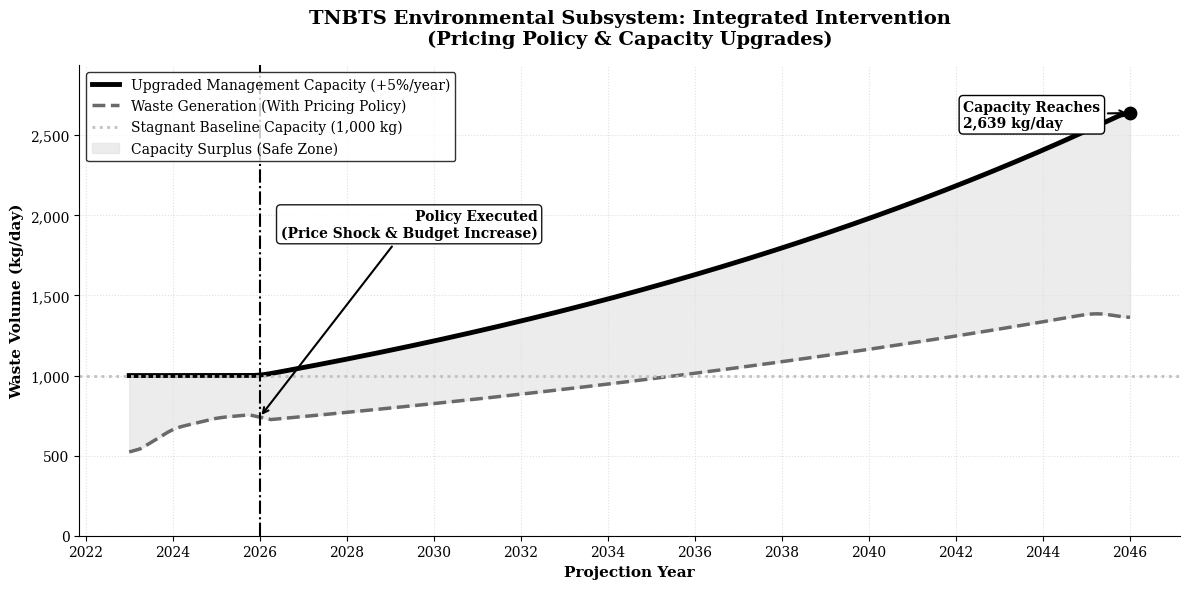

In [ ]:
# ==========================================
# 4. VISUALISASI GRAFIK
# ==========================================
plt.rcParams.update({
    'font.family': 'serif', 'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black',
    'ytick.color': 'black', 'axes.grid': True, 'grid.color': '#e0e0e0',
    'grid.linestyle': ':', 'legend.frameon': True, 'legend.edgecolor': 'black'
})

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df["Date"], df["Kapasitas_Smooth"], color="black", linestyle="-", linewidth=3.5, label="Upgraded Management Capacity (+5%/year)")
ax1.plot(df["Date"], df["Timbulan_Smooth"], color="dimgray", linestyle="--", linewidth=2.5, label="Waste Generation (With Pricing Policy)")
ax1.axhline(y=1000, color="silver", linestyle=":", linewidth=2, label="Stagnant Baseline Capacity (1,000 kg)")

ax1.fill_between(df["Date"], df["Timbulan_Smooth"], df["Kapasitas_Smooth"],
                 where=(df["Kapasitas_Smooth"] >= df["Timbulan_Smooth"]),
                 color="#e0e0e0", alpha=0.6, label="Capacity Surplus (Safe Zone)")

# Anotasi Intervensi
batas_prediksi = pd.Timestamp("2026-01-01")
val_timbulan_2026 = df.loc[df["Date"] == batas_prediksi, "Timbulan_Smooth"].values[0]
ax1.axvline(x=batas_prediksi, color="black", linestyle="-.", linewidth=1.5)
ax1.annotate(
    "Policy Executed\n(Price Shock & Budget Increase)",
    xy=(batas_prediksi, val_timbulan_2026), xytext=(200, 130), textcoords="offset points",
    fontsize=10, weight='bold', color='black',
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9), ha='right'
)

# Anotasi Hasil Akhir
end_date_val = df["Date"].iloc[-1]
end_cap_val = df["Kapasitas_Smooth"].iloc[-1]
ax1.scatter(end_date_val, end_cap_val, color="black", s=80, zorder=6)
ax1.annotate(
    f"Capacity Reaches\n{int(end_cap_val):,} kg/day",
    xy=(end_date_val, end_cap_val), xytext=(-120, -10), textcoords="offset points",
    fontsize=10, weight='bold', color='black',
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=1.0)
)

ax1.set_title("TNBTS Environmental Subsystem: Integrated Intervention\n(Pricing Policy & Capacity Upgrades)", fontsize=14, fontweight="bold", pad=15)
ax1.set_xlabel("Projection Year", fontsize=11, fontweight="bold")
ax1.set_ylabel("Waste Volume (kg/day)", fontsize=11, fontweight="bold")

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ",")))

ax1.set_ylim(bottom=0, top=max(df["Kapasitas_Smooth"]) + 300)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()